In [15]:
!pip install -q segmentation-models-pytorch albumentations pydicom

In [16]:
# Run once per Kaggle session
# !pip install -q segmentation-models-pytorch albumentations pydicom

import os, warnings, pickle
from glob import glob
from pathlib import Path

import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import segmentation_models_pytorch as smp
from segmentation_models_pytorch.losses import DiceLoss

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from tqdm import tqdm
import pydicom

warnings.filterwarnings("ignore")

# ── Device ────────────────────────────────────────────────────
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch  : {torch.__version__}")
print(f"Device   : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")

PyTorch  : 2.10.0+cu128
Device   : cuda
GPU      : Tesla T4


In [17]:
# ============================================================
# CẤU HÌNH HỆ THỐNG (Config)
# ============================================================
class Config:
    # ── Paths ─────────────────────────────────────────────────
    DS1_ROOT = "/kaggle/input/datasets/ozguraslank/brain-stroke-ct-dataset/Brain_Stroke_CT_Dataset"
    SAVE_DIR = "/kaggle/working"
    
    DS1_CLASSES = ["Bleeding", "Ischemia", "Normal"]
    CLS_MAP = {"Normal": 0, "Bleeding": 1, "Ischemia": 1}

    # ── Image ─────────────────────────────────────────────────
    IMG_H = 256
    IMG_W = 256

    # ── Training ──────────────────────────────────────────────
    BATCH_SIZE    = 8
    EPOCHS        = 50
    LR            = 1e-4
    NUM_WORKERS   = 2
    TRAIN_RATIO   = 0.70
    VAL_RATIO     = 0.15
    TEST_RATIO    = 0.15

    # ── Loss weights ──────────────────────────────────────────
    DICE_WEIGHT = 0.5   
    BCE_WEIGHT  = 0.5

cfg = Config()
print("✅ Nạp cấu hình thành công!")

✅ Nạp cấu hình thành công!


In [18]:
# ============================================================
# HÀM ĐỌC ẢNH VÀ NẠP DỮ LIỆU
# ============================================================
def dicom_to_rgb(path, h, w):
    dicom = pydicom.dcmread(path)
    img = dicom.pixel_array.astype(float)
    max_val = img.max()
    img = (np.maximum(img, 0) / max_val * 255.0) if max_val > 0 else np.zeros_like(img)
    img = cv2.resize(img.astype(np.uint8), (w, h))
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def png_to_rgb(path, h, w):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (w, h))
    return cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

def load_binary_mask(path, h, w):
    if path is None or not os.path.exists(path):
        return np.zeros((h, w), dtype=np.float32)
    
    # BƯỚC SỬA LỖI: Đọc ảnh màu thay vì trắng đen
    overlay = cv2.imread(path)
    if overlay is None:
        return np.zeros((h, w), dtype=np.float32)
        
    # Chuyển sang không gian màu HSV để lọc RIÊNG MÀU ĐỎ (vết đột quỵ bác sĩ tô)
    hsv = cv2.cvtColor(overlay, cv2.COLOR_BGR2HSV)
    
    # Dải màu đỏ trong HSV (Nó nằm ở 2 đầu dải màu)
    lower1, upper1 = np.array([0, 50, 50]), np.array([10, 255, 255])
    lower2, upper2 = np.array([170, 50, 50]), np.array([180, 255, 255])
    
    # Gom 2 dải màu lại
    mask = cv2.inRange(hsv, lower1, upper1) | cv2.inRange(hsv, lower2, upper2)
    
    # Đưa về dạng nhị phân 0-1 và resize
    mask = (mask > 0).astype(np.float32)
    mask = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
    
    return mask

def collect_ds1(root: str) -> pd.DataFrame:
    records = []
    for cat in cfg.DS1_CLASSES:
        cat_dir = os.path.join(root, cat)
        if not os.path.isdir(cat_dir):
            continue

        dcm_dir     = os.path.join(cat_dir, "DICOM")
        png_dir     = os.path.join(cat_dir, "PNG")
        mask_dir    = os.path.join(cat_dir, "MASKS")
        overlay_dir = os.path.join(cat_dir, "OVERLAY")

        img_files, img_types = [], []
        if os.path.isdir(dcm_dir):
            for ext in ["*.dcm", "*.DCM"]:
                for p in glob(os.path.join(dcm_dir, ext)):
                    img_files.append(p)
                    img_types.append("dicom")
        if os.path.isdir(png_dir):
            for p in sorted(glob(os.path.join(png_dir, "*.png"))):
                stem = Path(p).stem
                if not any(Path(f).stem == stem for f in img_files):
                    img_files.append(p)
                    img_types.append("png")

        cls_label = cfg.CLS_MAP.get(cat, 0)

        for img_path, img_type in zip(img_files, img_types):
            stem = Path(img_path).stem
            mask_path = None
            for mdir in [mask_dir, overlay_dir]:
                if os.path.isdir(mdir):
                    for ext in [".png", ".jpg", ".PNG", ".JPG"]:
                        cand = os.path.join(mdir, stem + ext)
                        if os.path.exists(cand):
                            mask_path = cand
                            break
                if mask_path: break

            records.append({
                "img_path" : img_path, "mask_path": mask_path,
                "img_type" : img_type, "category" : cat,
                "cls_label": cls_label, "source"   : "DS1",
            })

    df = pd.DataFrame(records)
    if df.empty:
        print(f"❌ LỖI: Không tìm thấy ảnh tại {root}")
    else:
        print(f"[DS1] {len(df)} images  |  with mask: {df['mask_path'].notna().sum()}")
    return df

# Tạo df_all
print("Đang quét dữ liệu, vui lòng đợi...")
df_ds1 = collect_ds1(cfg.DS1_ROOT)
df_all = df_ds1.copy()
df_all = df_all.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"\n✅ [TOTAL] {len(df_all)} samples (Stroke: {df_all['cls_label'].sum()}, Normal: {(df_all['cls_label']==0).sum()})")

Đang quét dữ liệu, vui lòng đợi...
[DS1] 6650 images  |  with mask: 2223

✅ [TOTAL] 6650 samples (Stroke: 2223, Normal: 4427)


--- TRỰC QUAN HÓA DỮ LIỆU THÔ ---


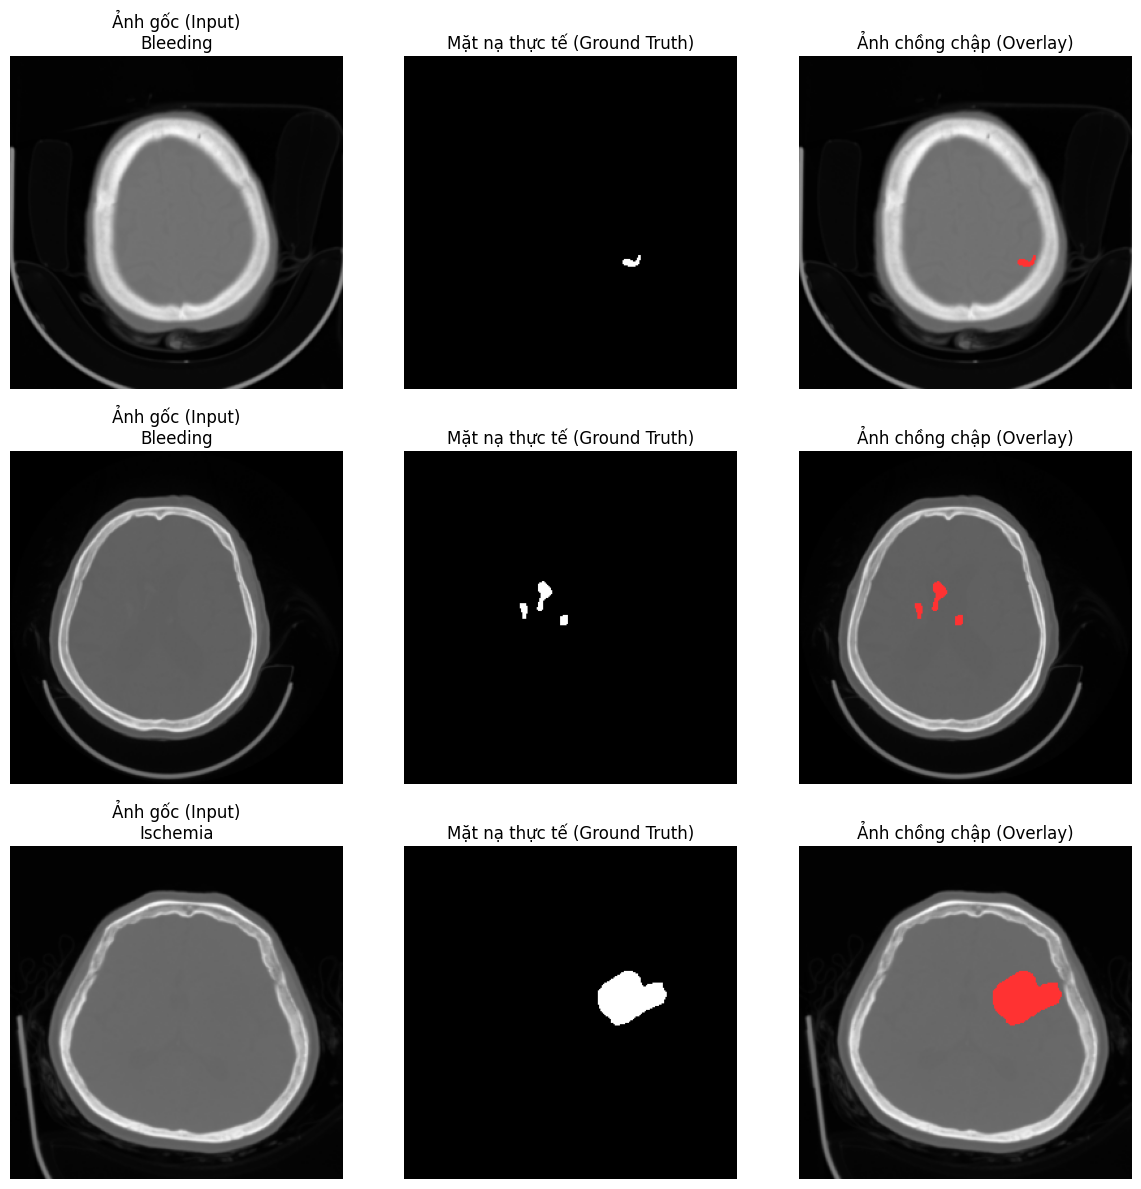

Tính tỷ lệ tổn thương: 100%|██████████| 2223/2223 [00:17<00:00, 126.24it/s]


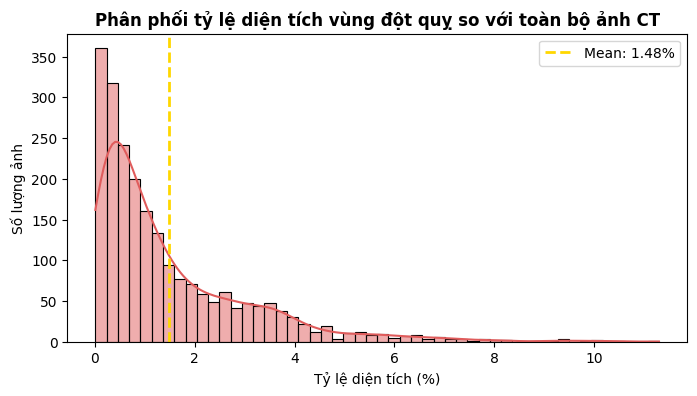

In [19]:
# ============================================================
# KHẢO SÁT VÀ PHÂN TÍCH DỮ LIỆU (EDA)
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Trực quan hóa một vài mẫu dữ liệu thô
def plot_eda_samples(df, num_samples=3):
    sample_df = df[df['mask_path'].notna()].sample(num_samples, random_state=42)
    fig, axes = plt.subplots(num_samples, 3, figsize=(12, 4 * num_samples))
    
    for i, (_, row) in enumerate(sample_df.iterrows()):
        if row['img_type'] == 'dicom':
            img = dicom_to_rgb(row['img_path'], cfg.IMG_H, cfg.IMG_W)
        else:
            img = png_to_rgb(row['img_path'], cfg.IMG_H, cfg.IMG_W)
            
        mask = load_binary_mask(row['mask_path'], cfg.IMG_H, cfg.IMG_W)
        
        axes[i, 0].imshow(img)
        axes[i, 0].set_title(f"Ảnh gốc (Input)\n{row['category']}")
        axes[i, 0].axis('off')
        
        axes[i, 1].imshow(mask, cmap='gray')
        axes[i, 1].set_title("Mặt nạ thực tế (Ground Truth)")
        axes[i, 1].axis('off')
        
        overlay = img.copy()
        overlay[mask == 1] = [255, 50, 50] # Tô màu đỏ
        axes[i, 2].imshow(overlay)
        axes[i, 2].set_title("Ảnh chồng chập (Overlay)")
        axes[i, 2].axis('off')
        
    plt.tight_layout()
    plt.show()

print("--- TRỰC QUAN HÓA DỮ LIỆU THÔ ---")
plot_eda_samples(df_all)

# 2. Phân tích tỷ lệ vùng tổn thương (Class Imbalance)
def analyze_lesion_ratio(df):
    ratios = []
    mask_df = df[df['mask_path'].notna()]
    for _, row in tqdm(mask_df.iterrows(), desc="Tính tỷ lệ tổn thương", total=len(mask_df)):
        mask = load_binary_mask(row['mask_path'], cfg.IMG_H, cfg.IMG_W)
        if mask.sum() > 0:
            ratio = mask.sum() / (cfg.IMG_H * cfg.IMG_W) * 100
            ratios.append(ratio)
            
    plt.figure(figsize=(8, 4))
    sns.histplot(ratios, bins=50, kde=True, color='#E05C5C')
    plt.axvline(np.mean(ratios), color='gold', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(ratios):.2f}%')
    plt.title("Phân phối tỷ lệ diện tích vùng đột quỵ so với toàn bộ ảnh CT", fontweight='bold')
    plt.xlabel("Tỷ lệ diện tích (%)")
    plt.ylabel("Số lượng ảnh")
    plt.legend()
    plt.show()

analyze_lesion_ratio(df_all)

In [20]:
train_val_df, test_df = train_test_split(
    df_all, test_size=cfg.TEST_RATIO,
    stratify=df_all["cls_label"], random_state=42)

val_relative = cfg.VAL_RATIO / (cfg.TRAIN_RATIO + cfg.VAL_RATIO)

train_df, val_df = train_test_split(
    train_val_df, test_size=val_relative,
    stratify=train_val_df["cls_label"], random_state=42)

print(f"Train : {len(train_df)}")
print(f"Val   : {len(val_df)}")
print(f"Test  : {len(test_df)}")

test_df.to_csv(os.path.join(cfg.SAVE_DIR, "test_set.csv"), index=False)

Train : 4654
Val   : 998
Test  : 998


In [76]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Thêm dòng này để ngăn OpenCV "đánh nhau" với Dataloader của PyTorch
cv2.setNumThreads(0)
def crop_and_resize_pair(image, mask, target_h=256, target_w=256):
    """
    Tìm tọa độ sọ não và cắt CẢ ẢNH VÀ MASK để chúng luôn khớp nhau.
    """
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# ĐÂY LÀ ĐOẠN SỬA LỖI SẬP DATALOADER
    if not contours:
        # Dù ảnh có đen thui hay lỗi, vẫn PHẢI resize về đúng chuẩn trước khi trả về
        res_img = cv2.resize(image, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
        res_mask = cv2.resize(mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)
        return res_img, res_mask

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    cropped_img = image[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]

    resized_img = cv2.resize(cropped_img, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    resized_mask = cv2.resize(cropped_mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    return resized_img, resized_mask

In [79]:
import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

# Thêm dòng này để ngăn OpenCV "đánh nhau" với Dataloader của PyTorch
cv2.setNumThreads(0)

# ==========================================
# 1. HÀM CẮT ĐỒNG BỘ ẢNH VÀ MASK
# ==========================================
def crop_and_resize_pair(image, mask, target_h=256, target_w=256):
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    _, thresh = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if not contours:
        return image, mask # Trả về gốc nếu không tìm thấy sọ não

    c = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(c)

    # Cắt cả ảnh và mask theo đúng 1 tọa độ
    cropped_img = image[y:y+h, x:x+w]
    cropped_mask = mask[y:y+h, x:x+w]

    # Resize (Mask bắt buộc dùng INTER_NEAREST để không làm hỏng pixel nhãn)
    resized_img = cv2.resize(cropped_img, (target_w, target_h), interpolation=cv2.INTER_CUBIC)
    resized_mask = cv2.resize(cropped_mask, (target_w, target_h), interpolation=cv2.INTER_NEAREST)

    return resized_img, resized_mask

# ==========================================
# 2. THÔNG SỐ TRANSFORMS
# ==========================================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.Rotate(limit=20, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.4),
    A.GaussNoise(var_limit=(10.0, 50.0), p=0.3),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

val_transforms = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ToTensorV2(),
])

# ==========================================
# 3. CLASS DATASET CHÍNH
# ==========================================
class StrokeSegmentationDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transforms=None):
        self.df         = df.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Đọc ảnh
        if row["img_type"] == "dicom":
            try:
                img = dicom_to_rgb(row["img_path"], cfg.IMG_H, cfg.IMG_W)
            except Exception:
                img = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)
        else:
            try:
                img = png_to_rgb(row["img_path"], cfg.IMG_H, cfg.IMG_W)
            except Exception:
                img = np.zeros((cfg.IMG_H, cfg.IMG_W, 3), dtype=np.uint8)

        # Đọc mask
        mask = load_binary_mask(row["mask_path"], cfg.IMG_H, cfg.IMG_W)
# ĐÂY LÀ DÒNG BẢO VỆ CHỐNG SẬP WORKER
        mask = mask.astype(np.uint8)
        # Ép tất cả về [0, 255] và kiểu uint8
        if img.max() <= 1.0: 
            img = (img * 255.0)
        img = img.astype(np.uint8) 

        # ĐÂY LÀ ĐOẠN CỨU NGUY: Cắt đồng bộ ảnh và mask
        img, mask = crop_and_resize_pair(img, mask, cfg.IMG_H, cfg.IMG_W)

        # Đưa qua Augmentation & Normalization
        if self.transforms:
            augmented = self.transforms(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"]
        else:
            img  = torch.from_numpy(img.transpose(2, 0, 1)).float() / 255.0
            mask = torch.from_numpy(mask)

        mask = mask.unsqueeze(0).float()
        
        return img, mask

# ==========================================
# 4. KHỞI TẠO LẠI DATALOADER
# ==========================================
train_dataset = StrokeSegmentationDataset(train_df, train_transforms)
val_dataset   = StrokeSegmentationDataset(val_df,   val_transforms)
test_dataset  = StrokeSegmentationDataset(test_df,  val_transforms)

train_loader = DataLoader(train_dataset, batch_size=cfg.BATCH_SIZE, shuffle=True,  num_workers=cfg.NUM_WORKERS, pin_memory=True, persistent_workers=True)
val_loader   = DataLoader(val_dataset,   batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=cfg.NUM_WORKERS, pin_memory=True, persistent_workers=True)
test_loader  = DataLoader(test_dataset,  batch_size=cfg.BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Batches – train: {len(train_loader)}  val: {len(val_loader)}  test: {len(test_loader)}")

Batches – train: 582  val: 125  test: 125


In [22]:
class StrokeUNetPlusPlus(nn.Module):
    def __init__(self):
        super().__init__()
        # Sử dụng UnetPlusPlus thay vì Unet
        self.unet = smp.UnetPlusPlus(
            encoder_name    = "efficientnet-b0",
            encoder_weights = "imagenet",
            in_channels     = 3,
            classes         = 1,
            activation      = None,
        )

    def forward(self, x):
        # Trực tiếp trả về output của U-Net++ (chỉ có segmentation)
        return self.unet(x)

model = StrokeUNetPlusPlus().to(DEVICE)
print("Model U-Net++ rebuilt OK")

Model U-Net++ rebuilt OK


In [23]:
# Cài đặt thư viện torchinfo (chỉ chạy 1 lần)
!pip install -q torchinfo
from torchinfo import summary

# Hiển thị bảng tóm tắt cấu trúc và số lượng tham số của mô hình
# Kích thước đầu vào mô phỏng: (Batch_Size, Channels, Height, Width)
summary(model, 
        input_size=(cfg.BATCH_SIZE, 3, cfg.IMG_H, cfg.IMG_W),
        col_names=["input_size", "output_size", "num_params", "trainable"],
        col_width=20,
        row_settings=["var_names"]
)

Layer (type (var_name))                                                Input Shape          Output Shape         Param #              Trainable
StrokeUNetPlusPlus (StrokeUNetPlusPlus)                                [8, 3, 256, 256]     [8, 1, 256, 256]     --                   True
├─UnetPlusPlus (unet)                                                  [8, 3, 256, 256]     [8, 1, 256, 256]     --                   True
│    └─EfficientNetEncoder (encoder)                                   [8, 3, 256, 256]     [8, 3, 256, 256]     412,160              True
│    │    └─Conv2dStaticSamePadding (_conv_stem)                       [8, 3, 256, 256]     [8, 32, 128, 128]    864                  True
│    │    └─BatchNorm2d (_bn0)                                         [8, 32, 128, 128]    [8, 32, 128, 128]    64                   True
│    │    └─SiLU (_swish)                                              [8, 32, 128, 128]    [8, 32, 128, 128]    --                   --
│    │    └─ModuleList (

In [24]:
class HybridSegLoss(nn.Module):
    def __init__(self, w_dice: float = 0.5, w_bce: float = 0.5):
        super().__init__()
        self.w_dice = w_dice
        self.w_bce  = w_bce
        self.dice   = DiceLoss(mode="binary", smooth=1.0)
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        return (self.w_dice * self.dice(logits, targets) + self.w_bce * self.bce(logits, targets))

criterion = HybridSegLoss(w_dice=cfg.DICE_WEIGHT, w_bce=cfg.BCE_WEIGHT)

In [25]:
from torch.amp import autocast, GradScaler
scaler = GradScaler()

def compute_seg_metrics(seg_logits: torch.Tensor, seg_masks: torch.Tensor, threshold: float = 0.5) -> dict:
    probs = torch.sigmoid(seg_logits).detach()
    preds = (probs > threshold).float()
    eps   = 1e-6

    B = preds.shape[0]
    p = preds.view(B, -1)      # (B, H*W)
    t = seg_masks.view(B, -1)  # (B, H*W)

    inter = (p * t).sum(dim=1)                               
    union = p.sum(1) + t.sum(1) - inter
    
    # Dice và IoU
    dice  = (2.0 * inter + eps) / (p.sum(1) + t.sum(1) + eps)
    iou   = (inter + eps) / (union + eps)

    # Các thành phần TP, FP, FN
    tp = inter
    fp = (p * (1 - t)).sum(dim=1)
    fn = ((1 - p) * t).sum(dim=1)

    # CẬP NHẬT: Thêm eps vào tử số để công bằng với ảnh Normal
    prec = (tp + eps) / (tp + fp + eps)
    rec  = (tp + eps) / (tp + fn + eps)
    
    # F1 Score
    f1   = 2 * (prec * rec) / (prec + rec + eps)

    return {
        "dice": dice.mean().item(), 
        "iou": iou.mean().item(),
        "prec": prec.mean().item(),
        "rec": rec.mean().item(),
        "f1": f1.mean().item()
    }

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    # 1. Bổ sung khởi tạo prec, rec, f1
    totals = dict(loss=0, dice=0, iou=0, prec=0, rec=0, f1=0)
    n = 0

    for imgs, masks in tqdm(loader, desc="  Train", leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        # Giải phóng memory thay vì set thành 0
        optimizer.zero_grad(set_to_none=True)

        # Sử dụng Mixed Precision (AMP) để tăng tốc độ train
        with autocast(device_type="cuda"):
            seg_logits = model(imgs)
            loss = criterion(seg_logits, masks)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()

        bs = imgs.size(0)
        totals["loss"] += loss.item() * bs

        seg_m = compute_seg_metrics(seg_logits, masks)
        totals["dice"] += seg_m["dice"] * bs
        totals["iou"]  += seg_m["iou"]  * bs
        # 2. Bổ sung cộng dồn prec, rec, f1
        totals["prec"] += seg_m["prec"] * bs
        totals["rec"]  += seg_m["rec"]  * bs
        totals["f1"]   += seg_m["f1"]   * bs
        n += bs

    return {k: v / n for k, v in totals.items()}

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    # 1. Bổ sung khởi tạo prec, rec, f1
    totals = dict(loss=0, dice=0, iou=0, prec=0, rec=0, f1=0)
    n = 0

    for imgs, masks in tqdm(loader, desc="  Val  ", leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)

        with autocast(device_type="cuda"):
            seg_logits = model(imgs)
            loss = criterion(seg_logits, masks)

        bs = imgs.size(0)
        totals["loss"] += loss.item() * bs

        seg_m = compute_seg_metrics(seg_logits, masks)
        totals["dice"] += seg_m["dice"] * bs
        totals["iou"]  += seg_m["iou"]  * bs
        # 2. Bổ sung cộng dồn prec, rec, f1
        totals["prec"] += seg_m["prec"] * bs
        totals["rec"]  += seg_m["rec"]  * bs
        totals["f1"]   += seg_m["f1"]   * bs
        n += bs

    return {k: v / n for k, v in totals.items()}

Starting U-Net++ Segmentation Training (Full Metrics)

Epoch 1/50  lr=1.00e-04


  [Train] loss=0.5396  dice=0.3831  iou=0.3772  prec=0.5215  rec=0.7058  f1=0.3831
  [Val  ] loss=0.4785  dice=0.6866  iou=0.6731  prec=0.8938  rec=0.7354  f1=0.6866
  ✔ Best model saved  (val_dice=0.6866)

Epoch 2/50  lr=9.99e-05


  [Train] loss=0.4596  dice=0.5703  iou=0.5552  prec=0.7192  rec=0.7569  f1=0.5703
  [Val  ] loss=0.4239  dice=0.6280  iou=0.6010  prec=0.6538  rec=0.8917  f1=0.6280

Epoch 3/50  lr=9.96e-05


  [Train] loss=0.3938  dice=0.6311  iou=0.6117  prec=0.7777  rec=0.7669  f1=0.6311
  [Val  ] loss=0.3497  dice=0.7190  iou=0.6918  prec=0.8210  rec=0.8226  f1=0.7189
  ✔ Best model saved  (val_dice=0.7190)

Epoch 4/50  lr=9.91e-05


  [Train] loss=0.3665  dice=0.6502  iou=0.6323  prec=0.8179  rec=0.7594  f1=0.6502
  [Val  ] loss=0.3412  dice=0.7362  iou=0.7161  prec=0.9049  rec=0.7801  f1=0.7362
  ✔ Best model saved  (val_dice=0.7362)

Epoch 5/50  lr=9.84e-05


...

  [Train] loss=0.2378  dice=0.7748  iou=0.7523  prec=0.8910  rec=0.8250  f1=0.7748
  [Val  ] loss=0.1854  dice=0.8471  iou=0.8172  prec=0.9129  rec=0.8678  f1=0.8471

Epoch 47/50  lr=2.56e-06


  [Train] loss=0.2546  dice=0.7608  iou=0.7396  prec=0.8878  rec=0.8152  f1=0.7608
  [Val  ] loss=0.1852  dice=0.8474  iou=0.8159  prec=0.9013  rec=0.8766  f1=0.8474

Epoch 48/50  lr=1.88e-06


  [Train] loss=0.2422  dice=0.7777  iou=0.7552  prec=0.8920  rec=0.8267  f1=0.7777
  [Val  ] loss=0.1841  dice=0.8503  iou=0.8197  prec=0.9101  rec=0.8719  f1=0.8503

Epoch 49/50  lr=1.39e-06


  [Train] loss=0.2370  dice=0.7705  iou=0.7489  prec=0.8951  rec=0.8196  f1=0.7705
  [Val  ] loss=0.1844  dice=0.8500  iou=0.8199  prec=0.9142  rec=0.8699  f1=0.8500

Epoch 50/50  lr=1.10e-06


  [Train] loss=0.2456  dice=0.7728  iou=0.7505  prec=0.8916  rec=0.8248  f1=0.7728
  [Val  ] loss=0.1846  dice=0.8503  iou=0.8203  prec=0.9151  rec=0.8691  f1=0.8503

Training complete.  Best val Dice: 0.8512


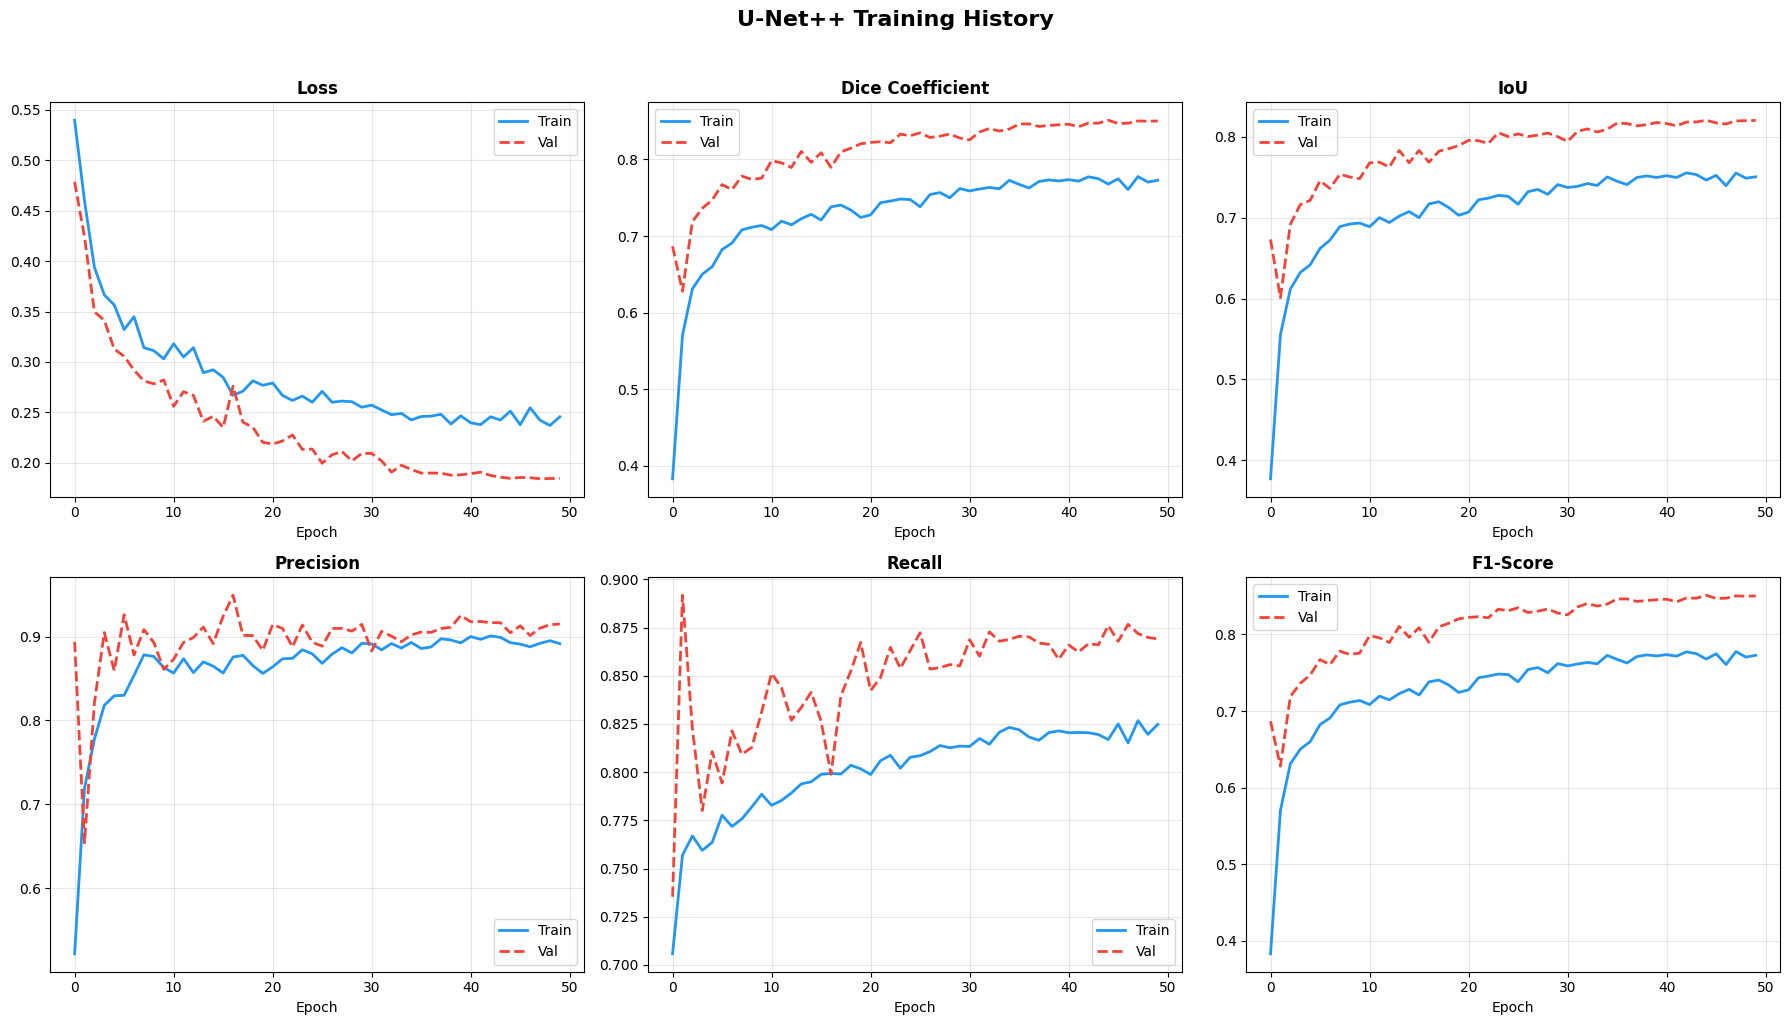

Saved: /kaggle/working/training_history_full.png


In [26]:
optimizer = optim.AdamW(model.parameters(), lr=cfg.LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg.EPOCHS, eta_min=1e-6)

# Khai báo thêm các mảng lưu trữ cho Precision, Recall, F1
history = {k: [] for k in [
    "train_loss", "val_loss", 
    "train_dice", "val_dice", 
    "train_iou",  "val_iou",
    "train_prec", "val_prec",
    "train_rec",  "val_rec",
    "train_f1",   "val_f1"
]}

best_val_dice   = 0.0
BEST_MODEL_PATH = os.path.join(cfg.SAVE_DIR, "best_unetplusplus_stroke.pth")

print("=" * 60)
print("Starting U-Net++ Segmentation Training (Full Metrics)")
print("=" * 60)

for epoch in range(1, cfg.EPOCHS + 1):
    print(f"\nEpoch {epoch}/{cfg.EPOCHS}  lr={scheduler.get_last_lr()[0]:.2e}")

    tr = train_one_epoch(model, train_loader, criterion, optimizer)
    vl = evaluate(model, val_loader, criterion)
    scheduler.step()

    # Cập nhật thêm prec, rec, f1 vào lịch sử
    for k in ["loss", "dice", "iou", "prec", "rec", "f1"]:
        history[f"train_{k}"].append(tr[k])
        history[f"val_{k}"].append(vl[k])

    # In log chi tiết ra màn hình
    print(f"  [Train] loss={tr['loss']:.4f}  dice={tr['dice']:.4f}  iou={tr['iou']:.4f}  prec={tr['prec']:.4f}  rec={tr['rec']:.4f}  f1={tr['f1']:.4f}")
    print(f"  [Val  ] loss={vl['loss']:.4f}  dice={vl['dice']:.4f}  iou={vl['iou']:.4f}  prec={vl['prec']:.4f}  rec={vl['rec']:.4f}  f1={vl['f1']:.4f}")

    if vl["dice"] > best_val_dice:
        best_val_dice = vl["dice"]
        torch.save({
            "epoch"      : epoch,
            "model_state": model.state_dict(),
            "optimizer"  : optimizer.state_dict(),
            "val_dice"   : best_val_dice,
        }, BEST_MODEL_PATH)
        print(f"  ✔ Best model saved  (val_dice={best_val_dice:.4f})")

print("\n" + "=" * 60)
print(f"Training complete.  Best val Dice: {best_val_dice:.4f}")
print("=" * 60)

# ============================================================
# HÀM VẼ BIỂU ĐỒ MỚI (LƯỚI 2x3)
# ============================================================
def plot_history_full(history: dict, save_path: str):
    metrics = [
        ("loss", "Loss"),
        ("dice", "Dice Coefficient"),
        ("iou",  "IoU"),
        ("prec", "Precision"),
        ("rec",  "Recall"),
        ("f1",   "F1-Score")
    ]
    
    # Tạo lưới biểu đồ 2 hàng x 3 cột
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for ax, (key, title) in zip(axes, metrics):
        ax.plot(history[f"train_{key}"], label="Train", color="#2196F3", lw=2)
        ax.plot(history[f"val_{key}"],   label="Val", color="#F44336", lw=2, linestyle="--")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.set_xlabel("Epoch")
        ax.legend()
        ax.grid(True, alpha=0.3)

    plt.suptitle("U-Net++ Training History", fontsize=16, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig(save_path, dpi=300, bbox_inches="tight") # Chỉnh DPI lên 300 để ảnh nét hơn khi cho vào Word
    plt.show()
    print(f"Saved: {save_path}")

plot_history_full(history, os.path.join(cfg.SAVE_DIR, "training_history_full.png"))

Loaded best model from epoch 45  (val_dice=0.8512)


Testing: 100%|██████████| 125/125 [00:39<00:00,  3.19it/s]



TEST SET RESULTS
Segmentation  Dice : 0.8517
Segmentation  IoU  : 0.8209


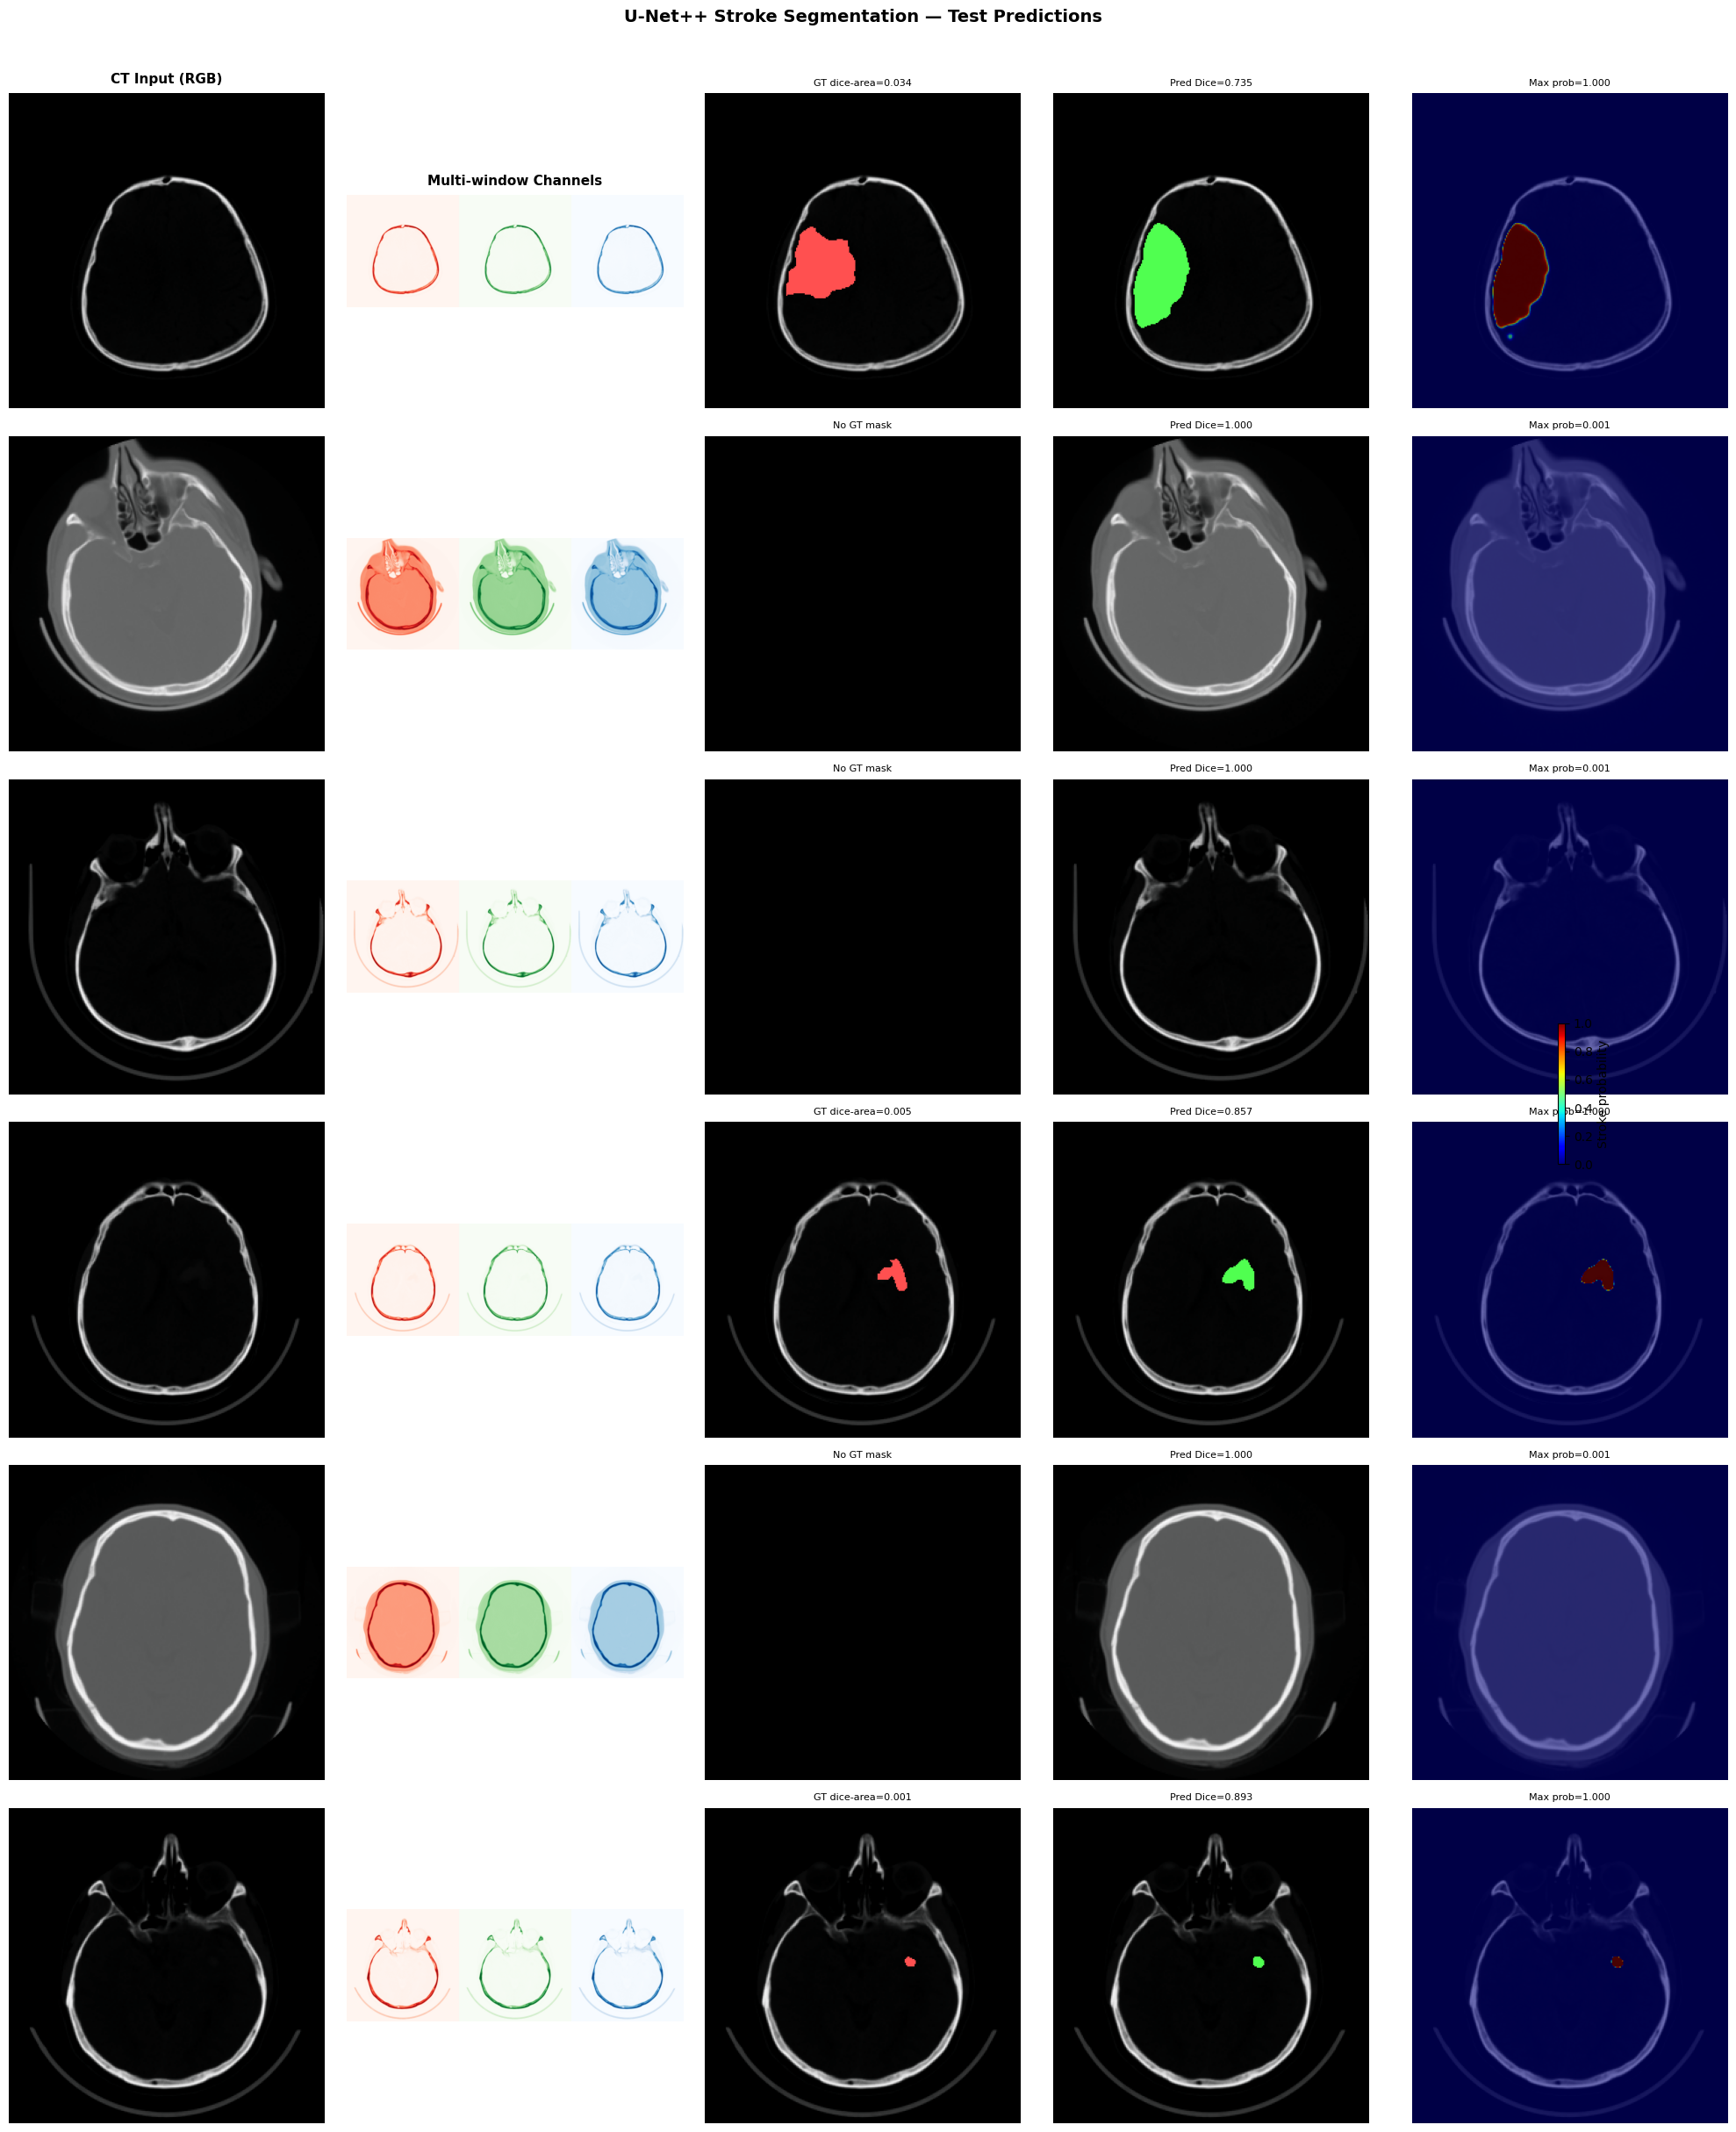

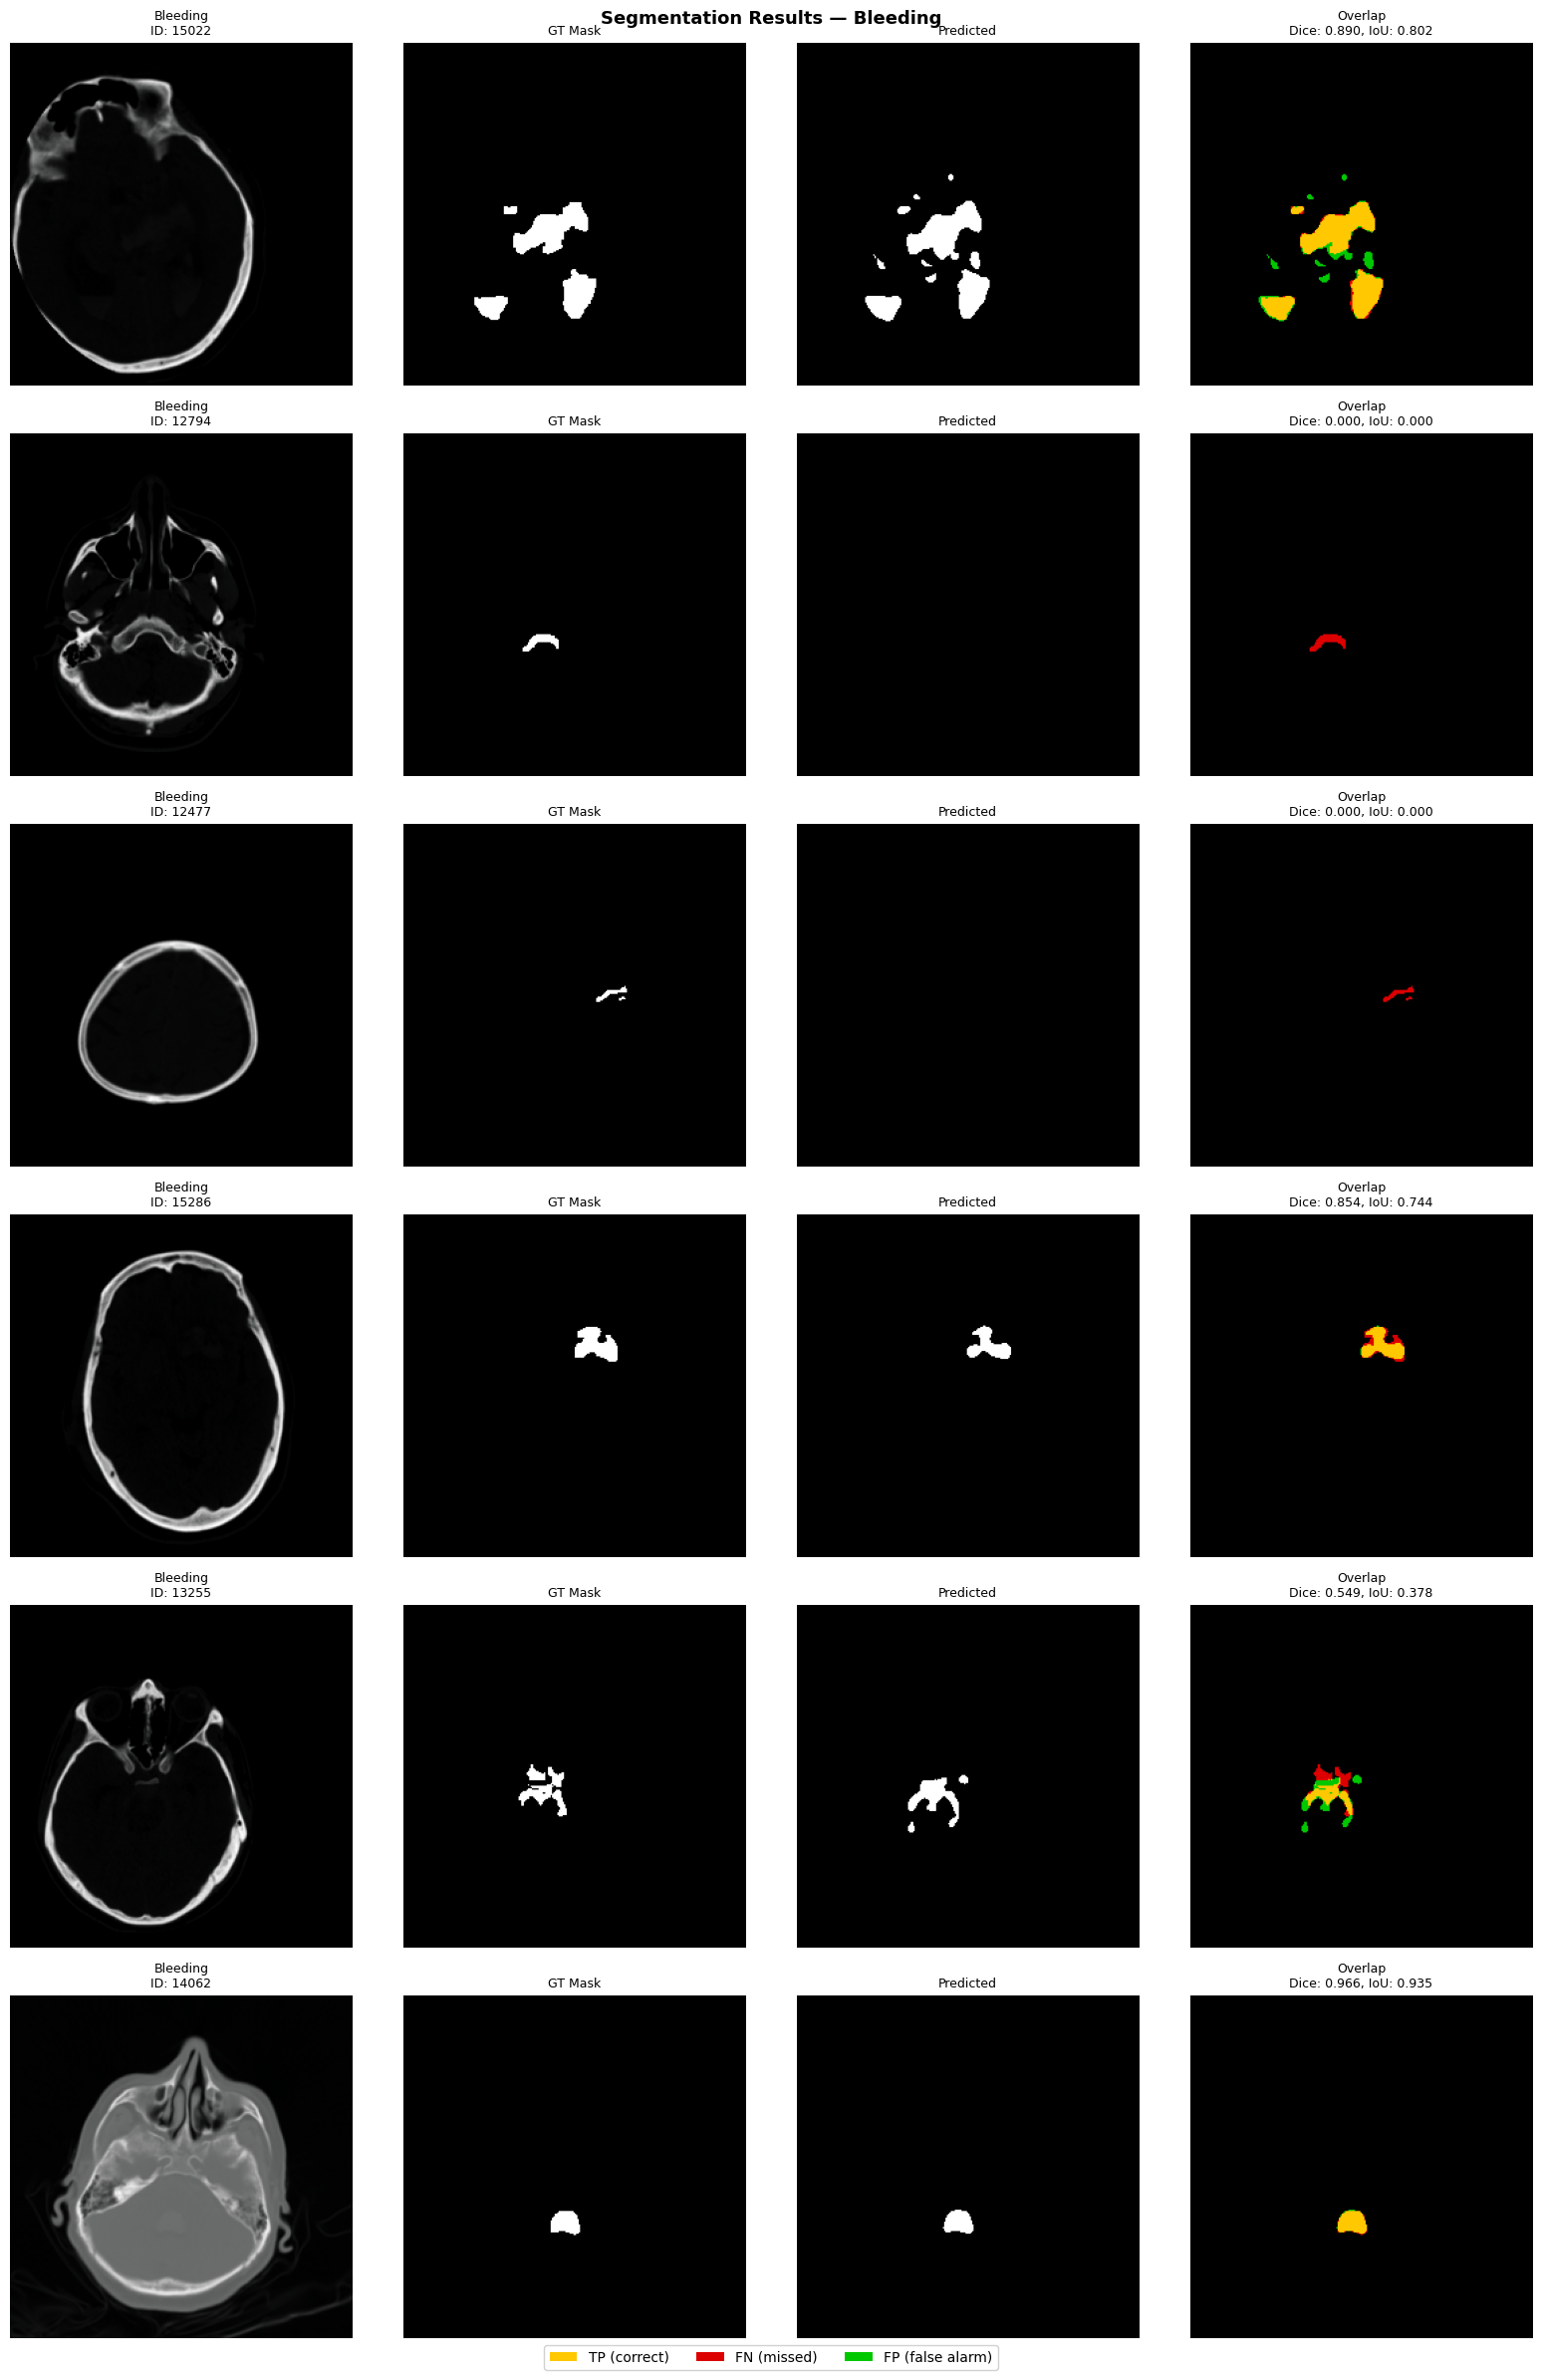

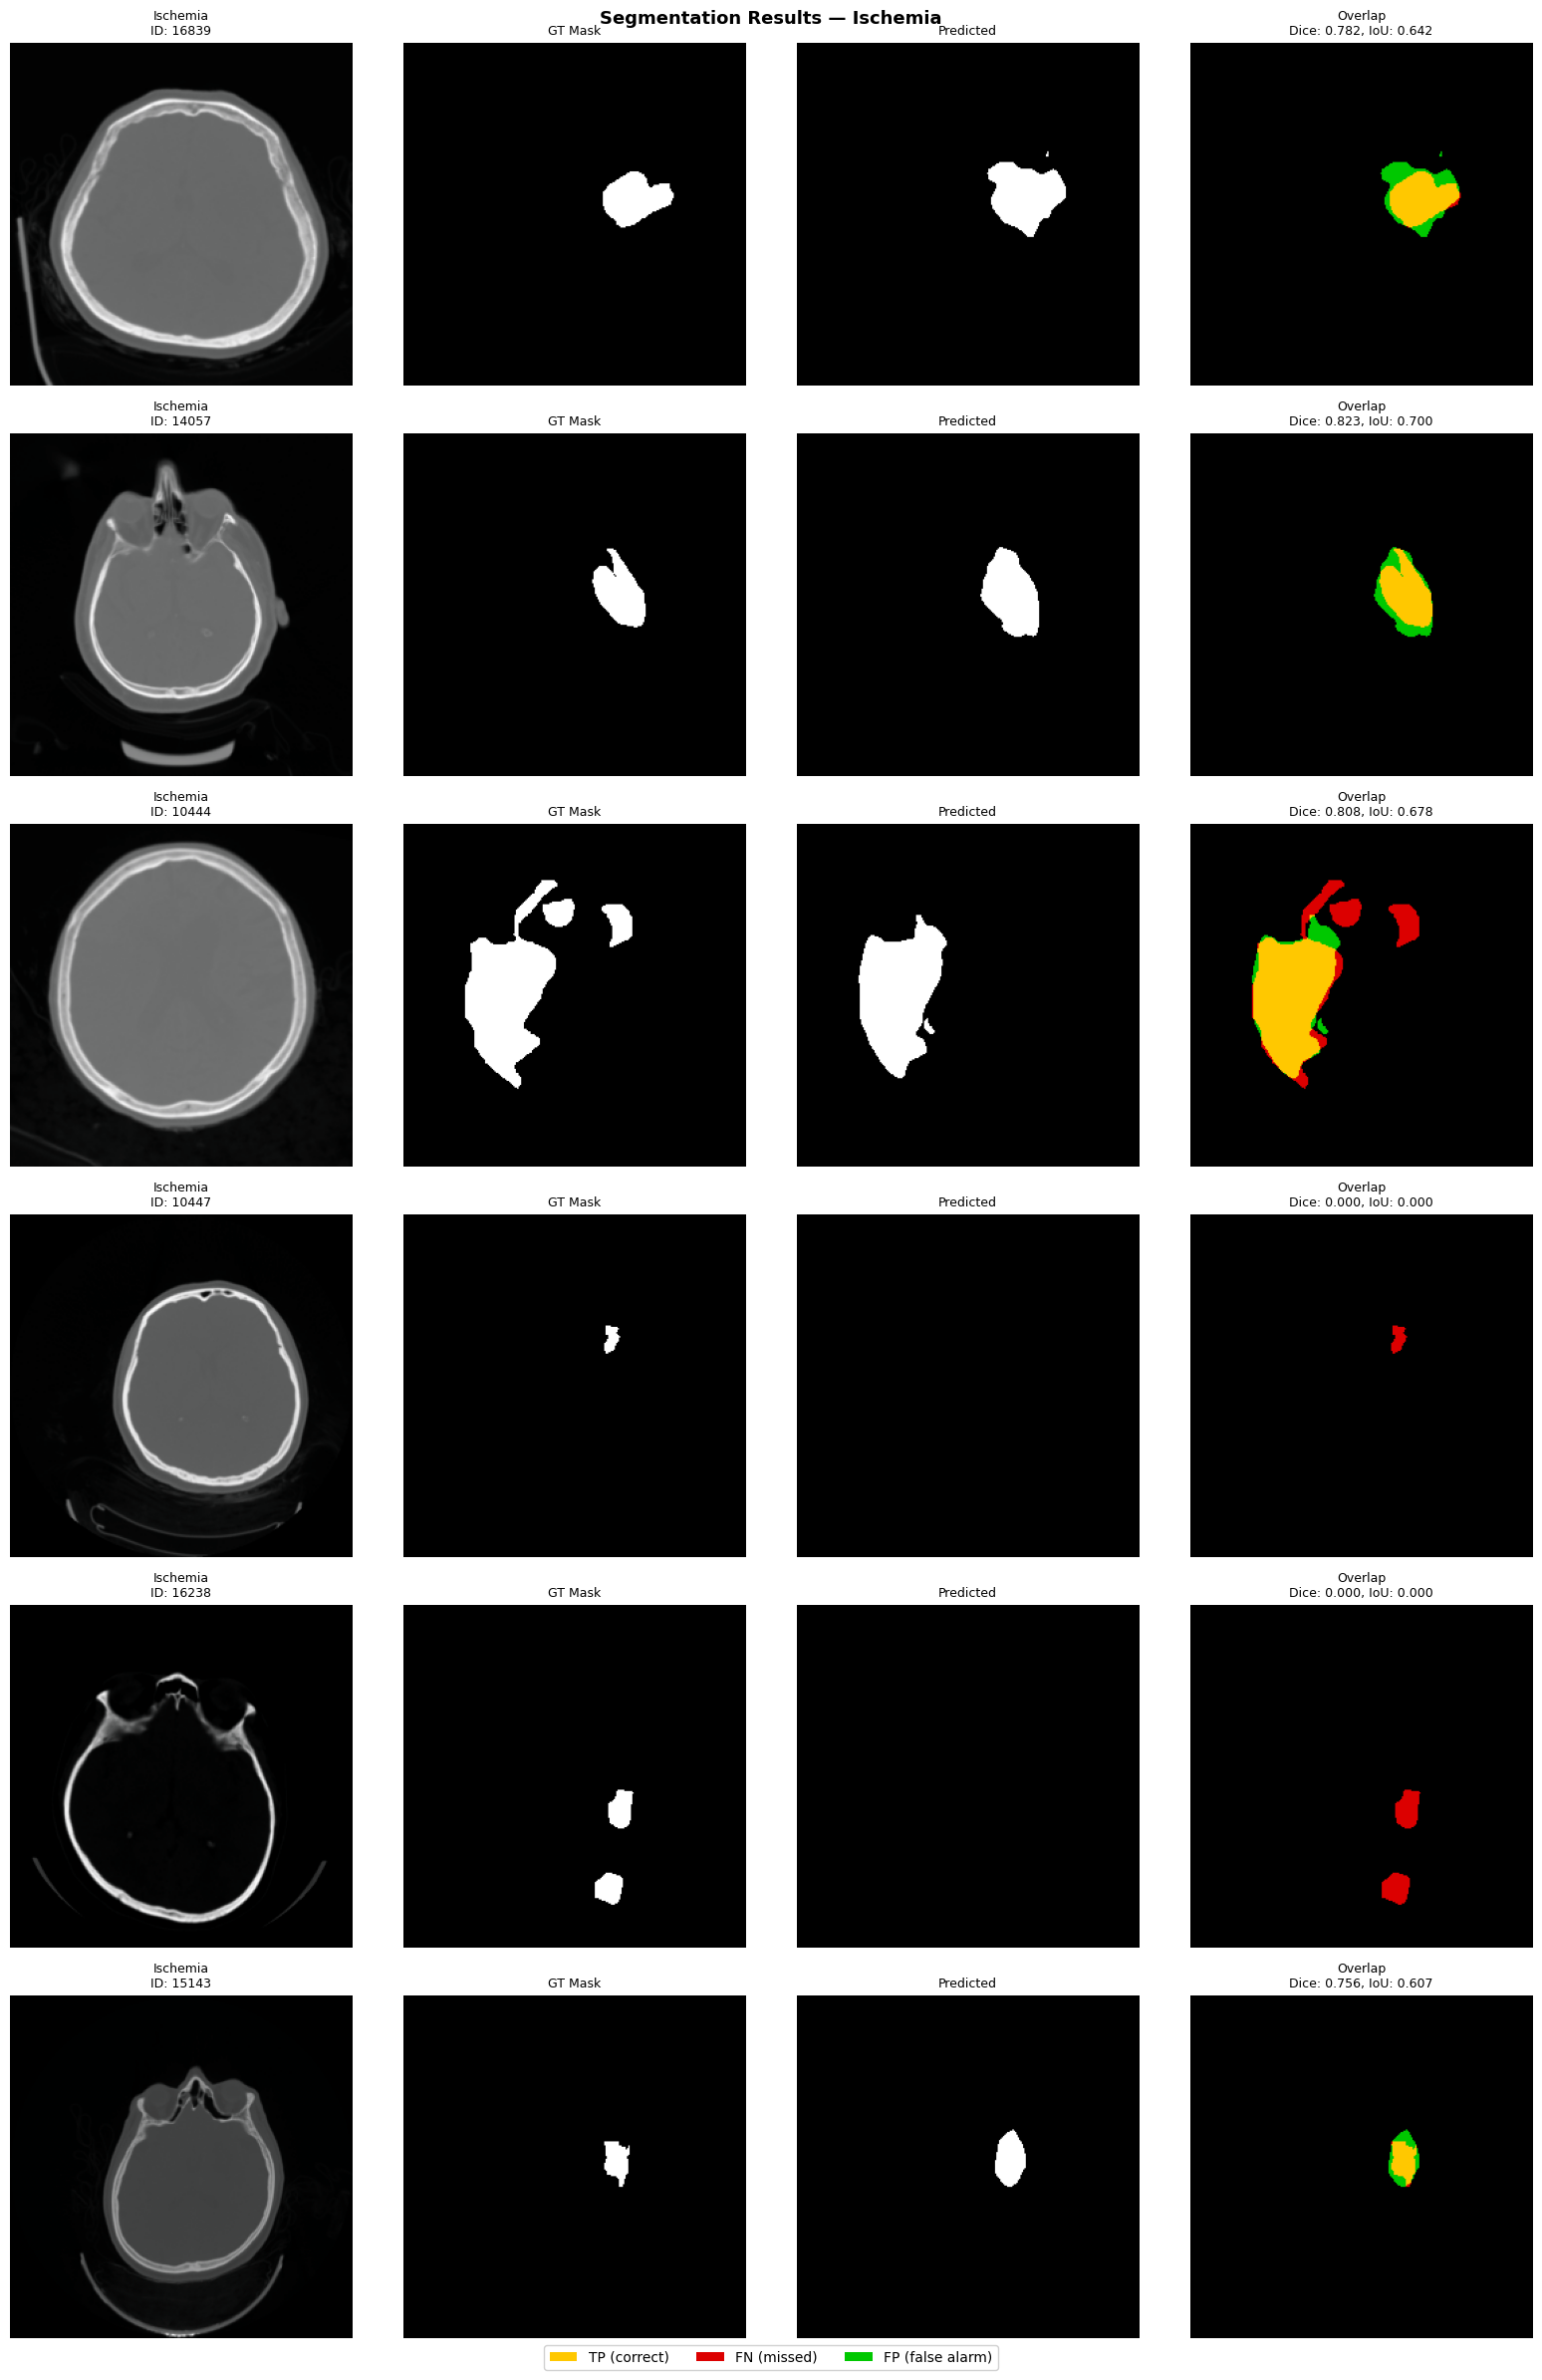

In [27]:
import matplotlib.cm as cm
import os
import cv2
import torch.nn.functional as F
import numpy as np

checkpoint = torch.load(BEST_MODEL_PATH, map_location=DEVICE)
model.load_state_dict(checkpoint["model_state"])
model.eval()

print(f"Loaded best model from epoch {checkpoint['epoch']}  (val_dice={checkpoint['val_dice']:.4f})")

# ============================================================
# 1. ĐÁNH GIÁ ĐẦY ĐỦ 6 CHỈ SỐ TRÊN TẬP TEST 
# ============================================================
all_dice, all_iou, all_prec, all_rec, all_f1, all_acc = [], [], [], [], [], []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader, desc="Testing"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        seg_logits = model(imgs)

        probs = torch.sigmoid(seg_logits)
        preds = (probs > 0.5).float()
        eps = 1e-6

        B = preds.shape[0]
        p = preds.view(B, -1)
        t = masks.view(B, -1)

        inter = (p * t).sum(dim=1)
        union = p.sum(1) + t.sum(1) - inter

        dice = (2.0 * inter + eps) / (p.sum(1) + t.sum(1) + eps)
        iou = (inter + eps) / (union + eps)

        tp = inter
        fp = (p * (1 - t)).sum(dim=1)
        fn = ((1 - p) * t).sum(dim=1)
        tn = ((1 - p) * (1 - t)).sum(dim=1)

        prec = (tp + eps) / (tp + fp + eps)
        rec = (tp + eps) / (tp + fn + eps)
        f1 = 2 * (prec * rec) / (prec + rec + eps)
        acc = (tp + tn) / (tp + tn + fp + fn + eps)

        all_dice.extend(dice.cpu().numpy())
        all_iou.extend(iou.cpu().numpy())
        all_prec.extend(prec.cpu().numpy())
        all_rec.extend(rec.cpu().numpy())
        all_f1.extend(f1.cpu().numpy())
        all_acc.extend(acc.cpu().numpy())

print("\n" + "=" * 60)
print("🚀 BẢNG ĐÁNH GIÁ CHỈ SỐ TRÊN TẬP TEST 🚀")
print("=" * 60)
print(f"Pixel Accuracy : {np.mean(all_acc):.4f}")
print(f"Dice Score     : {np.mean(all_dice):.4f}")
print(f"IoU Score      : {np.mean(all_iou):.4f}")
print(f"Precision      : {np.mean(all_prec):.4f}")
print(f"Recall         : {np.mean(all_rec):.4f}")
print(f"F1-Score       : {np.mean(all_f1):.4f}")
print("=" * 60)


# ============================================================
# 2. Các hàm vẽ (Visualization)
# ============================================================
def denormalise(tensor: torch.Tensor) -> np.ndarray:
    mean = np.array(IMAGENET_MEAN)[:, None, None]
    std  = np.array(IMAGENET_STD )[:, None, None]
    img  = tensor.cpu().numpy() * std + mean
    img  = np.clip(img * 255, 0, 255).astype(np.uint8)
    return img.transpose(1, 2, 0)

@torch.no_grad()
def visualize_predictions(model, dataset, n_samples: int = 6, save_path: str = None):
    model.eval()
    sick_indices = [i for i in range(len(dataset)) if dataset[i][1].sum().item() > 0]
    if len(sick_indices) == 0:
        print("Không tìm thấy ca bệnh nào trong tập test để hiển thị!")
        return
        
    n_samples = min(n_samples, len(sick_indices))
    indices = np.random.choice(sick_indices, n_samples, replace=False)

    fig, axes = plt.subplots(n_samples, 5, figsize=(20, 4 * n_samples))
    if n_samples == 1: axes = axes[np.newaxis, :]
    col_titles = ["CT Input (RGB)", "Multi-window Channels", "Ground-Truth Mask", "Predicted Mask", "Probability Heatmap"]

    for col_idx, title in enumerate(col_titles):
        axes[0, col_idx].set_title(title, fontsize=11, fontweight="bold", pad=8)

    for row, idx in enumerate(indices):
        img_t, mask_t = dataset[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)
        seg_logit = model(inp)
        prob = torch.sigmoid(seg_logit)[0, 0].cpu().numpy()
        pred_mask = (prob > 0.5).astype(np.uint8)

        rgb = denormalise(img_t)
        gt_mask = mask_t[0].numpy()
        dice = (2 * (pred_mask * gt_mask).sum() + 1e-6) / (pred_mask.sum() + gt_mask.sum() + 1e-6)

        axes[row, 0].imshow(rgb)
        axes[row, 0].set_ylabel(f"Sample {idx}", fontsize=9)

        channel_montage = np.concatenate([
            cm.Reds(rgb[:, :, 0] / 255.0)[:, :, :3],
            cm.Greens(rgb[:, :, 1] / 255.0)[:, :, :3],
            cm.Blues(rgb[:, :, 2] / 255.0)[:, :, :3],
        ], axis=1)
        axes[row, 1].imshow(channel_montage)
        axes[row, 1].set_xlabel("Brain | Subdural | Bone", fontsize=8)

        if gt_mask.sum() > 0:
            overlay = rgb.copy()
            overlay[gt_mask > 0] = [255, 80, 80]
            axes[row, 2].imshow(overlay)
            axes[row, 2].set_title(f"GT dice-area={gt_mask.mean():.3f}", fontsize=8)
        else:
            axes[row, 2].imshow(np.zeros_like(gt_mask), cmap="gray")
            axes[row, 2].set_title("No GT mask", fontsize=8)

        overlay_pred = rgb.copy()
        overlay_pred[pred_mask > 0] = [80, 255, 80]
        axes[row, 3].imshow(overlay_pred)
        axes[row, 3].set_title(f"Pred Dice={dice:.3f}", fontsize=8)

        heatmap = cm.jet(prob)[:, :, :3]
        blend = 0.55 * heatmap + 0.45 * (rgb / 255.0)
        blend = np.clip(blend, 0, 1)
        axes[row, 4].imshow(blend)
        axes[row, 4].set_title(f"Max prob={prob.max():.3f}", fontsize=8)

    fig.colorbar(plt.cm.ScalarMappable(cmap="jet", norm=plt.Normalize(0, 1)), ax=axes[:, 4], fraction=0.03, pad=0.04, label="Stroke probability")
    for ax in axes.flatten(): ax.axis("off")

    plt.suptitle("U-Net++ Stroke Segmentation — Test Predictions (Lesion Cases Only)", fontsize=14, fontweight="bold", y=1.01)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

visualize_predictions(model, test_dataset, n_samples=6, save_path=os.path.join(cfg.SAVE_DIR, "test_predictions.png"))

@torch.no_grad()
def visualize_grid(model, dataset, df, category_filter=None, n_samples=6, threshold=0.5, save_path=None):
    model.eval()
    if category_filter:
        sub_df = df[df["category"] == category_filter].reset_index(drop=True)
    else:
        sub_df = df.reset_index(drop=True)

    match_idx = dataset.df.index[dataset.df["img_path"].isin(sub_df["img_path"])].tolist()
    
    
    sick_match_idx = [i for i in match_idx if dataset[i][1].sum().item() > 0]
    
    if len(sick_match_idx) == 0:
        print(f"No sick samples found for category='{category_filter}'")
        return

    chosen = np.random.choice(sick_match_idx, min(n_samples, len(sick_match_idx)), replace=False)
    fig, axes = plt.subplots(len(chosen), 4, figsize=(16, 4 * len(chosen)))
    if len(chosen) == 1: axes = axes[np.newaxis, :]

    for row, idx in enumerate(chosen):
        img_t, mask_t = dataset[idx]
        row_info = dataset.df.iloc[idx]
        inp = img_t.unsqueeze(0).to(DEVICE)
        seg_logit = model(inp)

        prob = torch.sigmoid(seg_logit)[0, 0].cpu().numpy()
        pred_mask = (prob > threshold).astype(np.uint8)
        gt_mask = mask_t[0].numpy().astype(np.uint8)

        eps = 1e-6
        inter = (pred_mask * gt_mask).sum()
        union = pred_mask.sum() + gt_mask.sum() - inter
        dice = (2 * inter + eps) / (pred_mask.sum() + gt_mask.sum() + eps)
        iou = (inter + eps) / (union + eps)

        H, W = gt_mask.shape
        overlap = np.zeros((H, W, 3), dtype=np.uint8)
        tp, fn, fp = (pred_mask == 1) & (gt_mask == 1), (pred_mask == 0) & (gt_mask == 1), (pred_mask == 1) & (gt_mask == 0)
        overlap[tp] = [255, 200, 0]
        overlap[fn] = [220, 0, 0]
        overlap[fp] = [0, 200, 0]

        mean, std = np.array([0.485, 0.456, 0.406])[:, None, None], np.array([0.229, 0.224, 0.225])[:, None, None]
        rgb = np.clip((img_t.numpy() * std + mean) * 255, 0, 255).astype(np.uint8).transpose(1, 2, 0)

        cat, fid = row_info.get("category", "Unknown"), str(row_info.get("img_path", "")).split("/")[-1].split(".")[0]
        axes[row, 0].imshow(rgb); axes[row, 0].set_title(f"{cat}\nID: {fid}", fontsize=9)
        
        gt_disp = np.zeros((H, W, 3), dtype=np.uint8)
        gt_disp[gt_mask == 1] = [255, 255, 255]
        axes[row, 1].imshow(gt_disp); axes[row, 1].set_title("GT Mask", fontsize=9)
        
        pd_disp = np.zeros((H, W, 3), dtype=np.uint8)
        pd_disp[pred_mask == 1] = [255, 255, 255]
        axes[row, 2].imshow(pd_disp); axes[row, 2].set_title("Predicted", fontsize=9)
        
        axes[row, 3].imshow(overlap); axes[row, 3].set_title(f"Overlap\nDice: {dice:.3f}, IoU: {iou:.3f}", fontsize=9)

        for ax in axes[row]: ax.axis("off")

    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor="#FFC800", label="TP (correct)"), Patch(facecolor="#DC0000", label="FN (missed)"), Patch(facecolor="#00C800", label="FP (false alarm)")]
    fig.legend(handles=legend_elements, loc="lower center", ncol=3, fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.01))
    plt.suptitle(f"Segmentation Results — {category_filter if category_filter else 'All'}", fontsize=13, fontweight="bold")
    plt.tight_layout()
    if save_path: plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

visualize_grid(model, test_dataset, test_df, category_filter="Bleeding", n_samples=6, save_path="/kaggle/working/viz_bleeding_grid.png")
visualize_grid(model, test_dataset, test_df, category_filter="Ischemia", n_samples=6, save_path="/kaggle/working/viz_ischemia_grid.png")

In [41]:
!pip install scikit-image
import skimage
print("Đã load xong thư viện!")

Đã load xong thư viện!


In [45]:
from skimage.measure import label, regionprops
import numpy as np
import torch

def clean_mask(mask, min_area=100):
    """
    Chỉ giữ lại các vùng có diện tích > min_area.
    Xóa sạch mọi đốm nhiễu li ti mà mô hình dự đoán sai.
    """
    mask = mask.astype(np.uint8)
    labeled_mask = label(mask)
    for region in regionprops(labeled_mask):
        if region.area < min_area: # Tùy chỉnh min_area (ví dụ 50, 100, 200)
            mask[labeled_mask == region.label] = 0
    return mask

# Trong hàm evaluate, áp dụng sau khi có preds:
# preds_np = (probs > 0.5).cpu().numpy()
# preds_cleaned = clean_mask(preds_np[0,0], min_area=200)

[TRAIN] Type: dicom | Dtype: uint8 | Min: 0 | Max: 253 | Mean: 45.6757
[TEST] Type: dicom | Dtype: uint8 | Min: 0 | Max: 253 | Mean: 26.1021


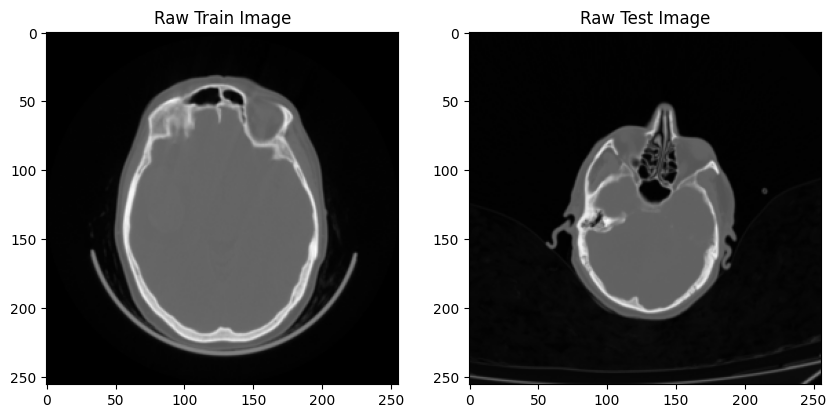

In [63]:
import matplotlib.pyplot as plt

def debug_raw_image(row, title):
    if row["img_type"] == "dicom":
        img = dicom_to_rgb(row["img_path"], cfg.IMG_H, cfg.IMG_W)
    else:
        img = png_to_rgb(row["img_path"], cfg.IMG_H, cfg.IMG_W)
        
    print(f"[{title}] Type: {row['img_type']} | Dtype: {img.dtype} | Min: {img.min()} | Max: {img.max()} | Mean: {img.mean():.4f}")
    return img

# Bốc ngẫu nhiên 1 ảnh Train và 1 ảnh Test
train_row = train_df[train_df['mask_path'].notnull()].iloc[0] # Lấy ca có bệnh
test_row = test_df[test_df['mask_path'].notnull()].iloc[0]

img_train = debug_raw_image(train_row, "TRAIN")
img_test = debug_raw_image(test_row, "TEST")

# Hiển thị
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_train)
plt.title("Raw Train Image")

plt.subplot(1, 2, 2)
plt.imshow(img_test)
plt.title("Raw Test Image")
plt.show()

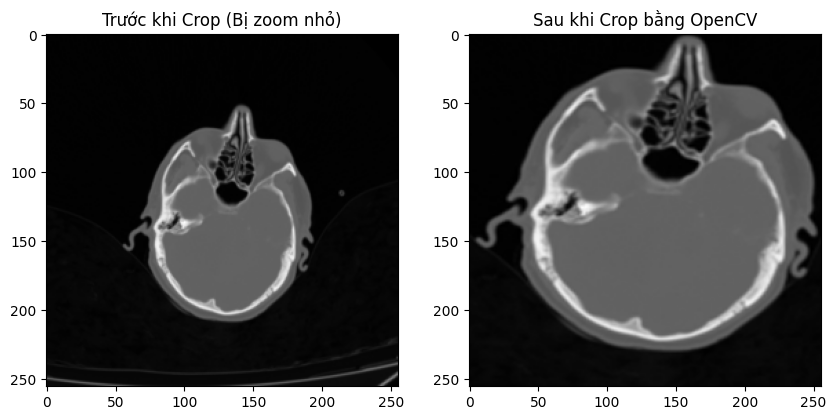

In [64]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def crop_brain_contour(image):
    """
    Hàm tìm và cắt phần sọ não, loại bỏ viền đen và nhiễu xung quanh.
    """
    # 1. Chuyển sang ảnh xám (grayscale) nếu ảnh là RGB
    if len(image.shape) == 3:
        gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    else:
        gray = image

    # 2. Làm mờ nhẹ để khử nhiễu (khử luôn phần đệm giường mờ mờ)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    
    # 3. Phân ngưỡng (Thresholding) để tách não (sáng) ra khỏi nền (đen)
    # Các pixel sáng hơn 10 sẽ biến thành trắng (255), nền đen giữ nguyên (0)
    _, thresh = cv2.threshold(blurred, 10, 255, cv2.THRESH_BINARY)

    # 4. Tìm các đường viền (contours)
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Nếu không tìm thấy viền nào (ảnh lỗi đen toàn tập), trả về ảnh gốc
    if not contours:
        return image 

    # 5. Tìm contour có diện tích lớn nhất (chắc chắn là sọ não)
    c = max(contours, key=cv2.contourArea)

    # 6. Lấy tọa độ hộp chữ nhật bao quanh sọ não
    x, y, w, h = cv2.boundingRect(c)

    # 7. Cắt ảnh theo tọa độ đó
    cropped_image = image[y:y+h, x:x+w]

    return cropped_image

# ==========================================
# THỬ NGHIỆM TRÊN TẤM ẢNH TEST LÚC NÃY
# ==========================================
# Giả sử img_test là tấm ảnh chưa crop (ảnh bên phải lúc nãy)
cropped_test_img = crop_brain_contour(img_test)

# Resize lại về đúng chuẩn (256x256) như mô hình mong đợi
cropped_resized_img = cv2.resize(cropped_test_img, (cfg.IMG_H, cfg.IMG_W), interpolation=cv2.INTER_CUBIC)

# Hiển thị so sánh
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_test, cmap='gray')
plt.title("Trước khi Crop (Bị zoom nhỏ)")

plt.subplot(1, 2, 2)
plt.imshow(cropped_resized_img, cmap='gray')
plt.title("Sau khi Crop bằng OpenCV")
plt.show()

In [74]:
checkpoint_path = 'best_unetplusplus_stroke.pth' 

try:
    # 1. Đọc toàn bộ file checkpoint
    checkpoint = torch.load(checkpoint_path, map_location=DEVICE)
    
    # 2. Chỉ trích xuất đúng phần 'model_state' (hoặc 'state_dict' tùy cách bạn lưu)
    if 'model_state' in checkpoint:
        model.load_state_dict(checkpoint['model_state'])
    elif 'state_dict' in checkpoint:
        model.load_state_dict(checkpoint['state_dict'])
    else:
        model.load_state_dict(checkpoint) # Backup trường hợp nó là weight thuần
        
    print("✅ Đã khôi phục thành công trí nhớ cho mô hình!")
except Exception as e:
    print(f"❌ Lỗi: {e}")

✅ Đã khôi phục thành công trí nhớ cho mô hình!


In [80]:
@torch.no_grad()
def evaluate_all_metrics_on_test_optimized(model, loader):
    model.eval()
    all_dice, all_prec, all_rec = [], [], []
    
    # Chúng ta sẽ chạy toàn bộ tập dữ liệu
    # Tạm thời tắt phần hậu xử lý (skimage) để lấy con số nhanh nhất
    
    print("--- Đang đánh giá toàn bộ tập Test... ---")
    
    for imgs, masks in tqdm(loader, desc="Testing"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        seg_logits = model(imgs)
        # Sử dụng hàm compute_seg_metrics chuẩn mà bạn đã có
        metrics = compute_seg_metrics(seg_logits, masks)
        
        # Chỉ cộng dồn nếu mask có bệnh (đúng theo cách chúng ta thống nhất)
        if masks.sum() > 0:
            all_dice.append(metrics["dice"])
            all_prec.append(metrics["prec"])
            all_rec.append(metrics["rec"])
            
    # In kết quả cuối cùng
    tqdm.write("\n" + "=" * 50)
    tqdm.write("🚀 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST 🚀")
    tqdm.write("=" * 50)
    tqdm.write(f"Dice Score: {np.mean(all_dice):.4f}")
    tqdm.write(f"Precision : {np.mean(all_prec):.4f}")
    tqdm.write(f"Recall    : {np.mean(all_rec):.4f}")
    tqdm.write("=" * 50)

# Chạy đánh giá
evaluate_all_metrics_on_test_optimized(model, test_loader)

--- Đang đánh giá toàn bộ tập Test... ---


Testing: 100%|██████████| 125/125 [01:10<00:00,  1.78it/s]


🚀 KẾT QUẢ ĐÁNH GIÁ TRÊN TẬP TEST 🚀
Dice Score: 0.7705
Precision : 0.8641
Recall    : 0.8313


Calculating Confusion Matrix: 100%|██████████| 125/125 [00:33<00:00,  3.77it/s]


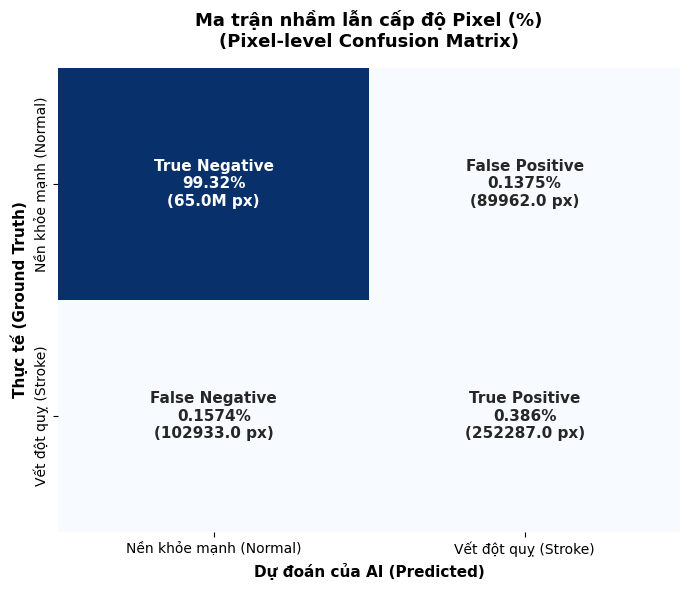

In [29]:
# ============================================================
# VẼ MA TRẬN NHẦM LẪN CẤP ĐỘ PIXEL (PIXEL-LEVEL CONFUSION MATRIX)
# Minh chứng rõ ràng nhất cho tỷ lệ Dương tính giả / Âm tính giả
# ============================================================
import seaborn as sns
import matplotlib.pyplot as plt

@torch.no_grad()
def plot_pixel_confusion_matrix(model, loader, save_path=None):
    model.eval()
    total_tp, total_fp, total_fn, total_tn = 0, 0, 0, 0
    
    for imgs, masks in tqdm(loader, desc="Calculating Confusion Matrix"):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        
        # Dự đoán
        seg_logits = model(imgs)
        probs = torch.sigmoid(seg_logits)
        preds = (probs > 0.5).float()
        
        # Duỗi phẳng (flatten) toàn bộ batch thành mảng 1D các pixels
        p = preds.view(-1)
        t = masks.view(-1)
        
        # Đếm tổng số lượng pixel cho 4 trường hợp
        total_tp += (p * t).sum().item()
        total_fp += (p * (1 - t)).sum().item()
        total_fn += ((1 - p) * t).sum().item()
        total_tn += ((1 - p) * (1 - t)).sum().item()
        
    # Tạo ma trận 2x2
    cm = np.array([[total_tn, total_fp], 
                   [total_fn, total_tp]])
    
    # Quy đổi sang tỷ lệ phần trăm (%) trên tổng số Pixel để dễ đọc
    cm_percentage = cm.astype('float') / cm.sum() * 100
    
    # Trực quan hóa bằng Heatmap của Seaborn
    plt.figure(figsize=(7, 6))
    
    # Định dạng nhãn hiển thị cả % và số lượng pixel thực tế (rút gọn)
    labels = np.array([
        [f"True Negative\n{cm_percentage[0,0]:.2f}%\n({cm[0,0]/1e6:.1f}M px)", 
         f"False Positive\n{cm_percentage[0,1]:.4f}%\n({cm[0,1]} px)"],
        [f"False Negative\n{cm_percentage[1,0]:.4f}%\n({cm[1,0]} px)", 
         f"True Positive\n{cm_percentage[1,1]:.3f}%\n({cm[1,1]} px)"]
    ])
    
    sns.heatmap(cm_percentage, annot=labels, fmt='', cmap='Blues', cbar=False,
                xticklabels=['Nền khỏe mạnh (Normal)', 'Vết đột quỵ (Stroke)'],
                yticklabels=['Nền khỏe mạnh (Normal)', 'Vết đột quỵ (Stroke)'],
                annot_kws={"size": 11, "weight": "bold"})
    
    plt.title('Ma trận nhầm lẫn cấp độ Pixel (%)\n(Pixel-level Confusion Matrix)', fontsize=13, fontweight='bold', pad=15)
    plt.ylabel('Thực tế (Ground Truth)', fontsize=11, fontweight='bold')
    plt.xlabel('Dự đoán của AI (Predicted)', fontsize=11, fontweight='bold')
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300)
    plt.show()

# Gọi hàm chạy
plot_pixel_confusion_matrix(model, test_loader, save_path="/kaggle/working/pixel_confusion_matrix.png")

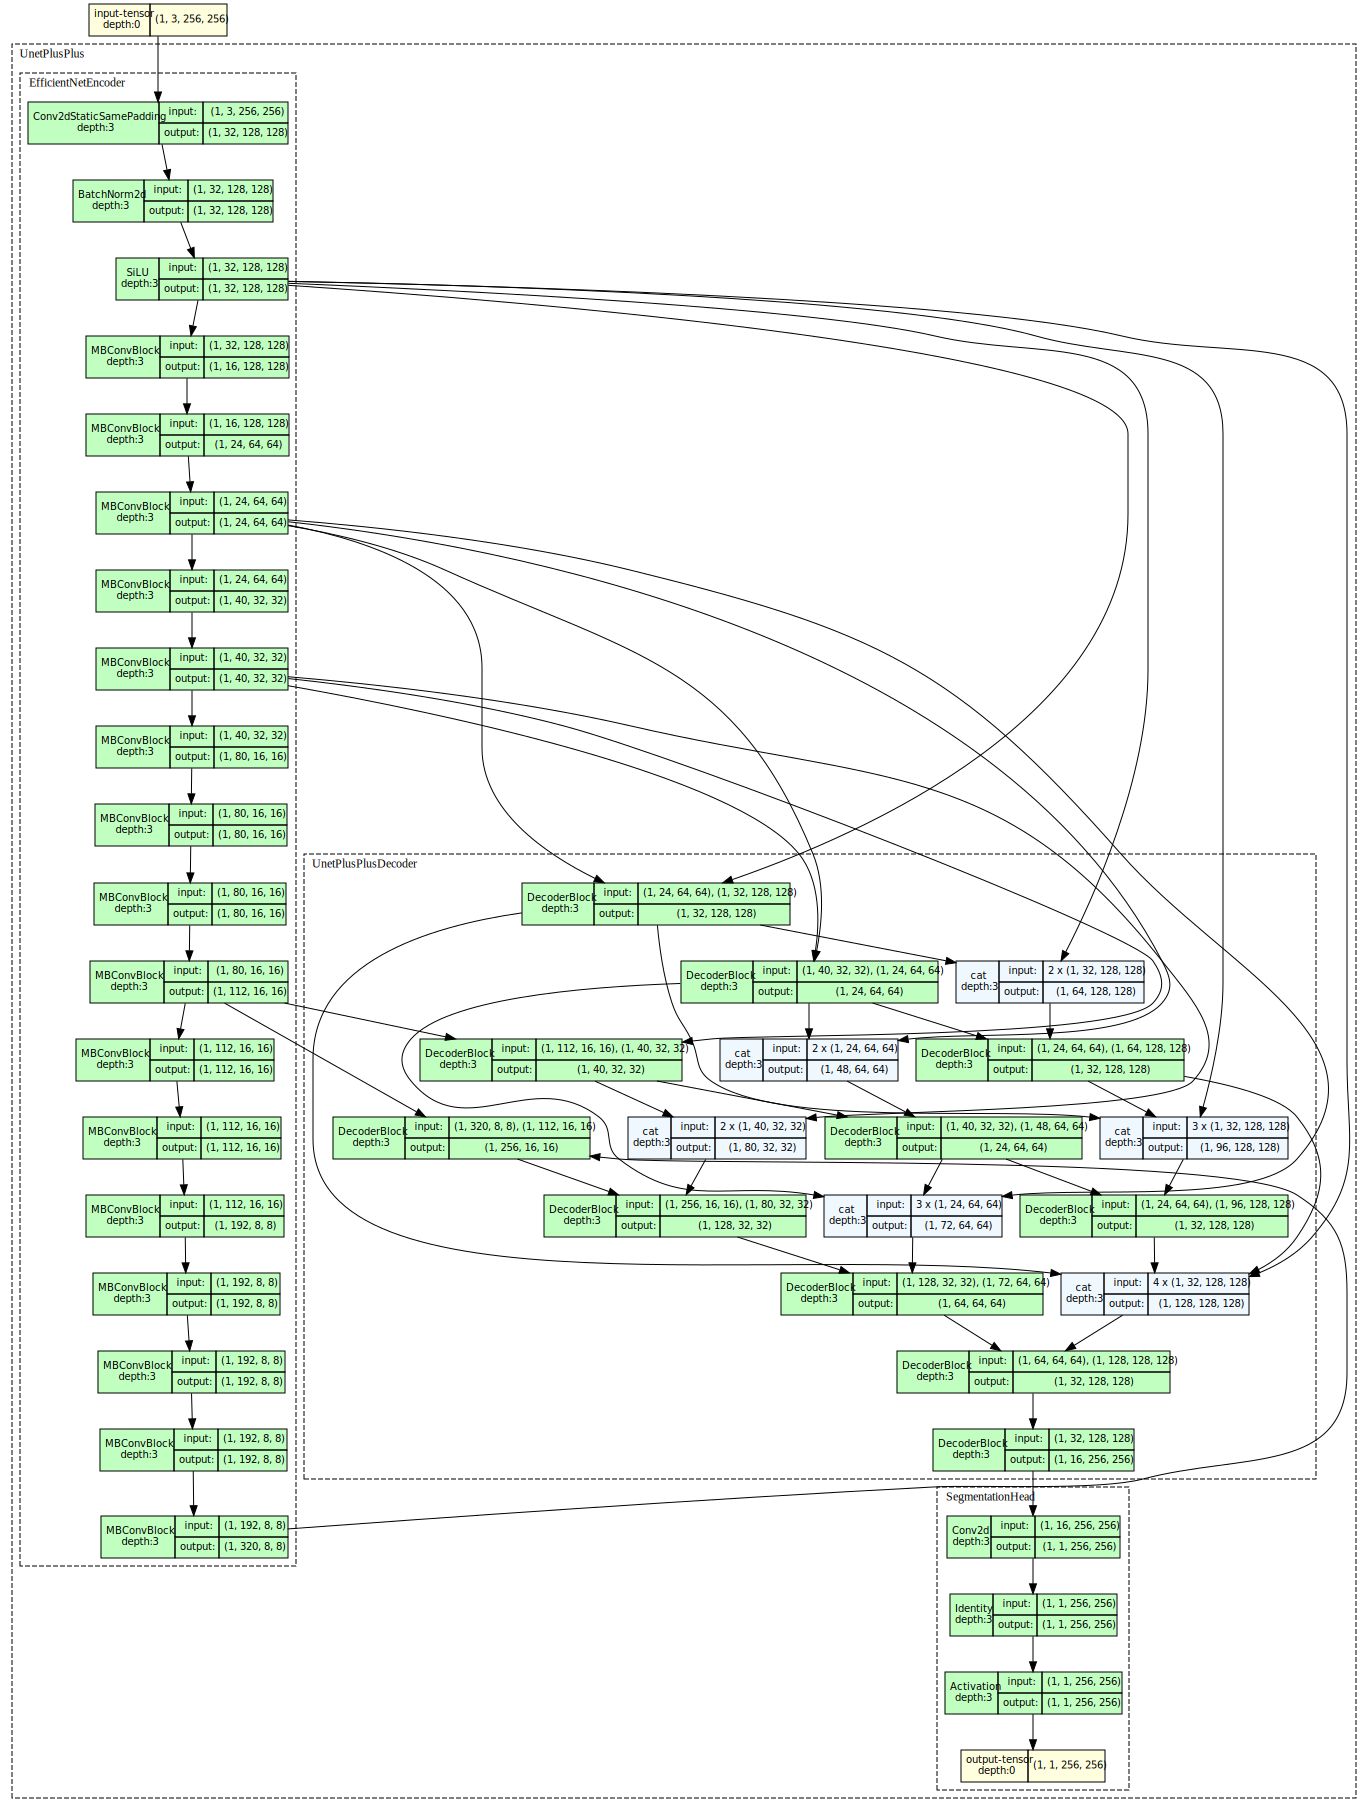

In [30]:
!pip install torchview
from torchview import draw_graph
# Khởi tạo model của bạn
model = StrokeUNetPlusPlus() 
# Vẽ kiến trúc
model_graph = draw_graph(model, input_size=(1, 3, 256, 256), expand_nested=True)
model_graph.visual_graph